# Capítulo 5 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 5. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Rd, Cp, g = 287.0, 1004.0, 9.8
Lv, Rv, eps = 2.5e6, 461.0, 0.622
e0, T00 = 0.6113, 273.15
Gamma_d = g/Cp

## T1 — Empuxo e *liquid loading*

**Solução.** Arquimedes por unidade de massa: $F/m = g(\rho_e - \rho_p)/\rho_p$. Na mesma pressão, $\rho = P/(\Re_d T_v)$, logo $\rho_e/\rho_p = T_{v,p}/T_{v,e}$ e
$$\frac{F}{m} = g\,\frac{T_{v,p} - T_{v,e}}{T_{v,e}}.\;∎$$
Com água líquida, $T_v = T(1 + 0{,}61r - r_L)$ (Cap. 1): cada g/kg de $r_L$ reduz $T_v$ em $T\times10^{-3} \approx 0{,}3$ K — gotículas em suspensão pesam como ar 0,3 K mais frio.

In [2]:
T = 300.0
print(f'ΔTv por 1 g/kg de água líquida: {T*1e-3:.2f} K')
print(f'empuxo equivalente: {g*T*1e-3/T*1e3:.1f} mm/s² — '
      'nuvens carregadas de água sobem menos (Cap. 14)')

ΔTv por 1 g/kg de água líquida: 0.30 K
empuxo equivalente: 9.8 mm/s² — nuvens carregadas de água sobem menos (Cap. 14)


## T2 — Linearização → oscilador harmônico

**Solução.** Deslocada de $z'$, a parcela tem $T_{v,p} = T_{v,0} - \Gamma_d z'$; o ambiente, $T_{v,e} = T_{v,0} + \gamma_e z'$ com $\gamma_e = \Delta T_{v,e}/\Delta z$. Então
$$\ddot z' = g\frac{T_{v,p}-T_{v,e}}{T_{v,e}} \approx -\frac{g}{T_{v,0}}(\Gamma_d + \gamma_e)\,z' \equiv -N^2 z'.$$
Equivalência com $\theta_v$: de $\theta_v \simeq T_v + \Gamma_d z$ (Cap. 3, T2), $d\theta_v/dz = \gamma_e + \Gamma_d$, logo $N^2 = (g/\theta_v)\,d\theta_v/dz$. ∎

In [3]:
# sympy: solução da EDO e período
t_, N_ = sp.symbols('t N', positive=True)
zf = sp.Function("z'")
solu = sp.dsolve(sp.Eq(zf(t_).diff(t_, 2), -N_**2*zf(t_)), zf(t_),
                 ics={zf(0): sp.Symbol('z_0'), zf(t_).diff(t_).subs(t_, 0): 0})
display(solu)
print('período = 2π/N ✓')

Eq(z'(t), z_0*cos(N*t))

período = 2π/N ✓


## T3 — $N$ e período por camada

In [4]:
for nome, gamma_e, T in [('troposfera padrão', -6.5e-3, 260.0),
                          ('estratosfera isotérmica', 0.0, 217.0),
                          ('camada de mistura (neutra)', -Gamma_d, 295.0)]:
    N2 = g/T*(Gamma_d + gamma_e)
    if N2 > 1e-10:
        print(f'{nome:28s}: N = {np.sqrt(N2)*1e3:5.1f} mHz | '
              f'período = {2*np.pi/np.sqrt(N2)/60:5.1f} min')
    else:
        print(f'{nome:28s}: N² = 0 — sem força restauradora: a parcela '
              'fica onde a deixarem (neutro).')
print('\nEstratosfera: N maior → mola mais dura → ondas mais rápidas e rasas.')

troposfera padrão           : N =  11.1 mHz | período =   9.4 min
estratosfera isotérmica     : N =  21.0 mHz | período =   5.0 min
camada de mistura (neutra)  : N² = 0 — sem força restauradora: a parcela fica onde a deixarem (neutro).

Estratosfera: N maior → mola mais dura → ondas mais rápidas e rasas.


## T4 — CAT no jato

**Solução.** $S = \Delta U/\Delta z = 20/500 = 0{,}04$ s⁻¹; $Ri = N^2/S^2 = 4\times10^{-4}/1{,}6\times10^{-3} = 0{,}25$ — exatamente no limiar: qualquer intensificação dispara turbulência. Cisalhamento crítico: $S_c = \sqrt{N^2/0{,}25} = 2N = 0{,}04$ s⁻¹ (ou seja, 20 m/s por 500 m).

## T5 — Contraexemplo local × não local

**Solução (um exemplo).** Perfil: $\theta_v = 303$ K na superfície, caindo a 301 K em 100 m (superadiabático), depois **crescendo suavemente** de 301 a 301,8 K entre 0,1 e 1,2 km, e inversão forte acima. O critério local classifica 0,1–1,2 km como *estável* (gradiente positivo!). Mas a parcela de superfície ($\theta_v = 303$ K) é mais quente que todo o ambiente até ~1,2 km — ela atravessa a camada inteira, que é portanto **instável não local**. O erro do critério local: ignora que estabilidade é propriedade de *trajetórias*, não de *pontos*; parcelas vindas de longe carregam seu $\theta_v$ de origem.

---
## N1 — Três regimes + contagem de oscilações

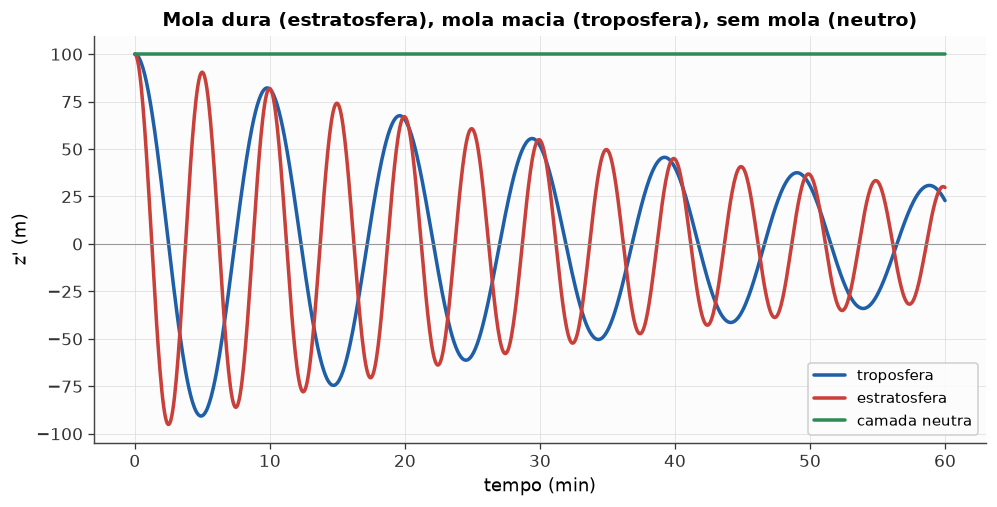

amplitude cai a 1/e em t = 2τ = 50 min → 5.1 oscilações completas


In [5]:
tau = 25*60.0
regimes = [('troposfera', (g/280.0)*(Gamma_d - 6.5e-3), CORES['azul']),
           ('estratosfera', (g/217.0)*Gamma_d, CORES['vermelho']),
           ('camada neutra', 0.0, CORES['verde'])]

t = np.linspace(0, 3600, 900)
fig, ax = plt.subplots(figsize=(10, 4.6))
for nome, N2, cor in regimes:
    sol = solve_ivp(lambda tt, y: [y[1], -N2*y[0] - y[1]/tau],
                    [0, 3600], [100.0, 0.0], dense_output=True, rtol=1e-9)
    ax.plot(t/60, sol.sol(t)[0], color=cor, label=nome)
ax.axhline(0, color='#999999', lw=0.7)
ax.set(xlabel='tempo (min)', ylabel="z' (m)",
       title='Mola dura (estratosfera), mola macia (troposfera), sem mola (neutro)')
ax.legend()
plt.show()

N_tropo = np.sqrt(regimes[0][1])
n_osc = 2*tau/(2*np.pi/N_tropo)
print(f'amplitude cai a 1/e em t = 2τ = {2*tau/60:.0f} min → '
      f'{n_osc:.1f} oscilações completas')

## N2 — Parcela no emagrama caseiro

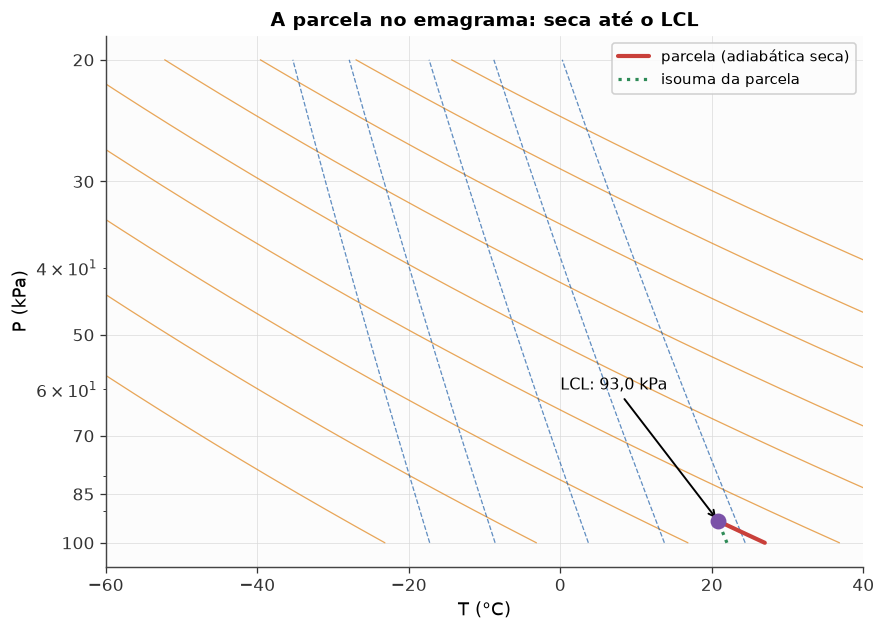

r = 17.2 g/kg | LCL = 93.0 kPa ≈ 631 m | regra 125·(T−Td) = 625 m ✓


In [6]:
P = np.linspace(100, 20, 300)
T_adiab = lambda th, P: th*(P/100.0)**(Rd/Cp)
def T_isouma(rs, P):
    e = rs*P/(eps + rs)
    return 1.0/(1.0/T00 - (Rv/Lv)*np.log(e/e0))

# parcela: T=27 °C, Td=22 °C a 100 kPa
T_p, Td_p = 300.15, 295.15
es_td = e0*np.exp((Lv/Rv)*(1/T00 - 1/Td_p))
r_p = eps*es_td/(100.0 - es_td)
theta_p = T_p            # já está em 100 kPa

# LCL: interseção da adiabática seca (θ=300,15) com a isouma r_p
from scipy.optimize import brentq
f = lambda PP: T_adiab(theta_p, PP) - T_isouma(r_p, PP)
P_lcl = brentq(f, 99.0, 50.0)
T_lclv = T_adiab(theta_p, P_lcl)

fig, ax = plt.subplots(figsize=(8.5, 6))
for th in np.arange(250, 411, 20):
    ax.plot(T_adiab(th, P) - 273.15, P, color=CORES['laranja'], lw=0.8, alpha=0.7)
for rs in [1e-3, 2e-3, 5e-3, 10e-3, 20e-3]:
    ax.plot(T_isouma(rs, P) - 273.15, P, '--', color=CORES['azul'], lw=0.8,
            alpha=0.7)
Pd = np.linspace(100, P_lcl, 50)
ax.plot(T_adiab(theta_p, Pd) - 273.15, Pd, color=CORES['vermelho'], lw=2.6,
        label='parcela (adiabática seca)')
ax.plot(T_isouma(r_p, Pd) - 273.15, Pd, color=CORES['verde'], lw=2.0, ls=':',
        label='isouma da parcela')
ax.scatter([T_lclv - 273.15], [P_lcl], s=80, color=CORES['roxo'], zorder=5)
ax.annotate(f'LCL: {P_lcl:.1f} kPa'.replace('.', ','),
            xy=(T_lclv - 273.15, P_lcl), xytext=(0, 60), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.2))
ax.set_yscale('log'); ax.invert_yaxis()
ax.set_yticks([100, 85, 70, 50, 30, 20]); ax.set_yticklabels(['100','85','70','50','30','20'])
ax.set(xlim=(-60, 40), xlabel='T (°C)', ylabel='P (kPa)',
       title='A parcela no emagrama: seca até o LCL')
ax.legend(loc='upper right')
plt.show()
z_lcl = Rd/g*0.5*(T_p + T_lclv)*np.log(100.0/P_lcl)
print(f'r = {1e3*r_p:.1f} g/kg | LCL = {P_lcl:.1f} kPa ≈ {z_lcl:.0f} m | '
      f'regra 125·(T−Td) = {125*(T_p-Td_p):.0f} m ✓')

## N3 — Estabilidade não local do perfil noturno

In [7]:
def classifica_local(z, thv):
    d = np.diff(thv)/np.diff(z)
    return np.where(d < -0.4, 'instável', np.where(d > 0.4, 'estável', 'neutro'))

def classifica_nao_local(z, thv):
    atrav = np.zeros(len(z)-1, bool)
    for i in range(len(z)):
        if i < len(z)-1 and thv[i] >= thv[i+1] - 1e-9:
            j = i
            while j < len(z)-1 and thv[i] >= thv[j+1] - 1e-9:
                atrav[j] = True; j += 1
        if i > 0 and thv[i] <= thv[i-1] + 1e-9:
            j = i
            while j > 0 and thv[i] <= thv[j-1] + 1e-9:
                atrav[j-1] = True; j -= 1
    return np.where(atrav, 'instável', classifica_local(z, thv))

z_n   = np.array([0.0, 0.05, 0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.2])
thv_n = np.array([296.0, 298.5, 300.0, 301.2, 302.0, 302.3, 302.5,
                  302.7, 304.5, 306.5])

loc, nl = classifica_local(z_n, thv_n), classifica_nao_local(z_n, thv_n)
for i in range(len(z_n)-1):
    print(f'{z_n[i]:.2f}–{z_n[i+1]:.2f} km: local={loc[i]:9s} não-local={nl[i]}')
print('\nÀ noite a inversão de radiação gruda o ar no chão: nenhuma parcela sobe,')
print('local e não-local coincidem (tudo estável/neutro) — o oposto da tarde.')

0.00–0.05 km: local=estável   não-local=estável
0.05–0.10 km: local=estável   não-local=estável
0.10–0.30 km: local=estável   não-local=estável
0.30–0.60 km: local=estável   não-local=estável
0.60–0.90 km: local=estável   não-local=estável
0.90–1.20 km: local=estável   não-local=estável
1.20–1.50 km: local=estável   não-local=estável
1.50–1.80 km: local=estável   não-local=estável
1.80–2.20 km: local=estável   não-local=estável

À noite a inversão de radiação gruda o ar no chão: nenhuma parcela sobe,
local e não-local coincidem (tudo estável/neutro) — o oposto da tarde.


## N4 — Jato crítico para a primeira camada turbulenta

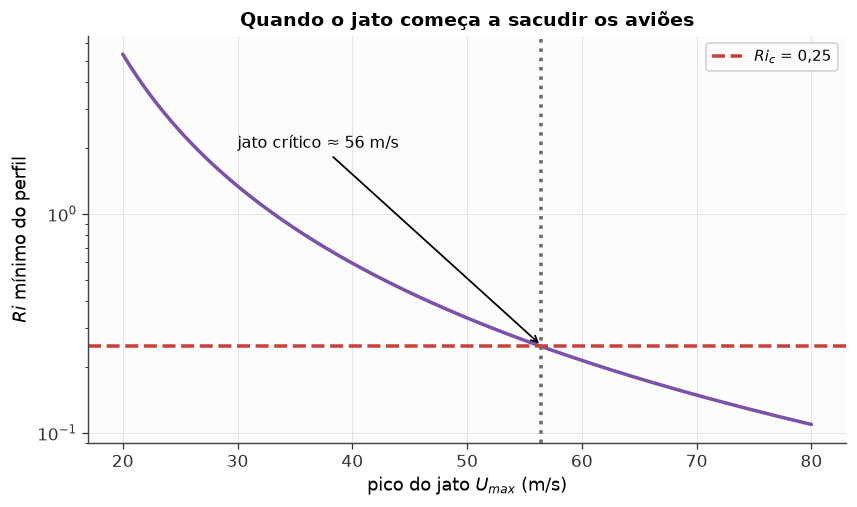

primeira camada com Ri < 0,25 quando U_max ≈ 56 m/s


In [8]:
z = np.linspace(0, 14e3, 60)
thv_p = 300 + 3.3e-3*z + np.where(z > 11.5e3, 12e-3*(z - 11.5e3), 0.0)
zm = 0.5*(z[1:] + z[:-1])
N2_p = g/(0.5*(thv_p[1:]+thv_p[:-1]))*np.diff(thv_p)/np.diff(z)

def Ri_min(Umax):
    U = 10 + (Umax - 10)*np.exp(-((z - 10e3)/2000.0)**2)
    S2 = (np.diff(U)/np.diff(z))**2
    return np.min(N2_p/np.maximum(S2, 1e-12))

Umaxs = np.linspace(20, 80, 200)
Rimins = np.array([Ri_min(U) for U in Umaxs])
U_crit = Umaxs[np.argmax(Rimins < 0.25)]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.semilogy(Umaxs, Rimins, color=CORES['roxo'])
ax.axhline(0.25, color=CORES['vermelho'], ls='--', label='$Ri_c$ = 0,25')
ax.axvline(U_crit, color=CORES['cinza'], ls=':')
ax.annotate(f'jato crítico ≈ {U_crit:.0f} m/s', xy=(U_crit, 0.25),
            xytext=(30, 2), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='pico do jato $U_{max}$ (m/s)', ylabel='$Ri$ mínimo do perfil',
       title='Quando o jato começa a sacudir os aviões')
ax.legend()
plt.show()
print(f'primeira camada com Ri < 0,25 quando U_max ≈ {U_crit:.0f} m/s')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*